In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_cpu_use_thunk_runtime=false"
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import corner
import dill, os
from astropy.time import Time
from datetime import datetime

import jax.numpy as jnp
import jax
from jax import random, config
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive, init_to_value
from numpyro import handlers
from jax import config
import arviz as az 
config.update('jax_enable_x64', True)

num_chains = 1
numpyro.set_host_device_count(num_chains)
print ('# jax device count:', jax.local_device_count())

# jax device count: 1


In [2]:
import jnkepler
print(jnkepler.__version__)
from numpyro_sample_orbits import *

0.2.4.post1.dev35


In [3]:
import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
sns.set_palette('colorblind')
plt.rcParams["figure.figsize"] = (18,6)
from matplotlib import rc
rc('text', usetex=False)

## load data from [Konopacky et al. (2016)](https://ui.adsabs.harvard.edu/abs/2016AJ....152...28K/abstract)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_66200/900533643.py:1: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv("hr8799_konopacky.txt", delim_whitespace='\s+')
/var/folders/qp/91qlh0v11sb02z6vb4nb_s0m0000gn/T/ipykernel_66200/900533643.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("hr8799_konopacky.txt", delim_whitespace='\s+')


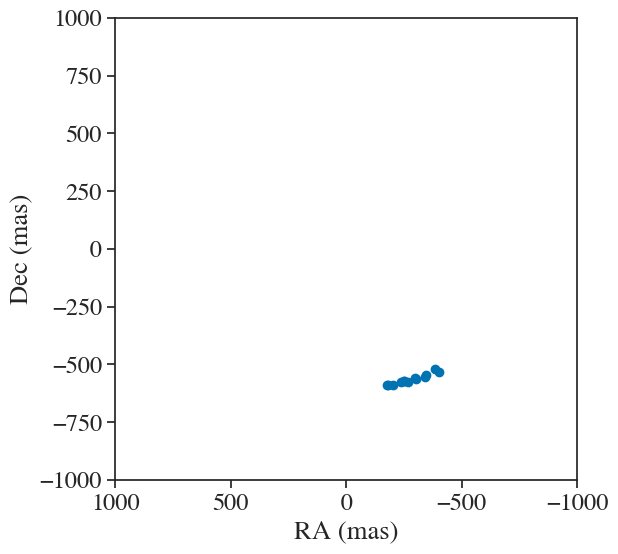

In [4]:
data = pd.read_csv("hr8799_konopacky.txt", delim_whitespace='\s+')
dt = [datetime.strptime(date, "%Y%b%d") for date in data.Date]
t = Time(dt, scale='utc')
data['mjd'] = t.mjd

t, x, xerr, y, yerr = np.array(data[['mjd', 'd_dx', 'd_dxerr', 'd_dy', 'd_dyerr']]).T
idx = ~np.isnan(x)

# minus sign so that it matches their Figure 2
# as -> mas
t, ra, raerr, dec, decerr = t[idx], -x[idx]*1e3, xerr[idx]*1e3, y[idx]*1e3, yerr[idx]*1e3

plt.xlim(1e3, -1e3)
plt.ylim(-1e3, 1e3)
plt.gca().set_aspect(1.)
plt.xlabel("RA (mas)")
plt.ylabel("Dec (mas)")
plt.errorbar(ra, dec, fmt='o', xerr=raerr, yerr=decerr);

## simulate data

In [ ]:
# true parameters
mass_true, mass_err = 1.5, 0.15
parallax_true, parallax_err = 24.46, 0.045

params_sim = {
    "mass": mass_true, "mass_err": mass_err, "parallax": parallax_true, "parallax_err": parallax_err,
    "period_yr": 112.7, "ecc": 0.02, "inc_deg": 29.4, "lnode_deg": 59., "omega_deg": 92.4, 
    "tau_mjd": Time(1995.4, scale='utc', format='decimalyear').mjd,
}

init_elements = get_init_elements(params_sim, t[0])

In [26]:
# simulate 'observed' mass and parallax
np.random.seed(124)
mass_obs_sim = mass_true + np.random.randn() * mass_err
parallax_obs_sim = parallax_true + np.random.randn() * parallax_err

init_elements['mass_obs_sim'] = np.round(mass_obs_sim, 2)
init_elements['parallax_obs_sim'] = np.round(parallax_obs_sim, 2)
init_elements['mass_err'] = mass_err 
init_elements['parallax_err'] = parallax_err

print(init_elements['mass_obs_sim'], init_elements['parallax_obs_sim'])

1.54 24.44


In [ ]:
cond_model = handlers.condition(model_relative_astrometry_radec_nocorr, data=init_elements)
pred = Predictive(cond_model, num_samples=1, return_sites=["ra", "dec"])
sim_obs = pred(random.PRNGKey(0), t=t, ra_obs=None, ra_err=raerr, dec_obs=None, dec_err=decerr,
               mass_obs=mass_true, mass_err=mass_err, parallax_obs=parallax_true, parallax_err=parallax_err)
ra_sim, dec_sim = sim_obs['ra'][0], sim_obs['dec'][0]

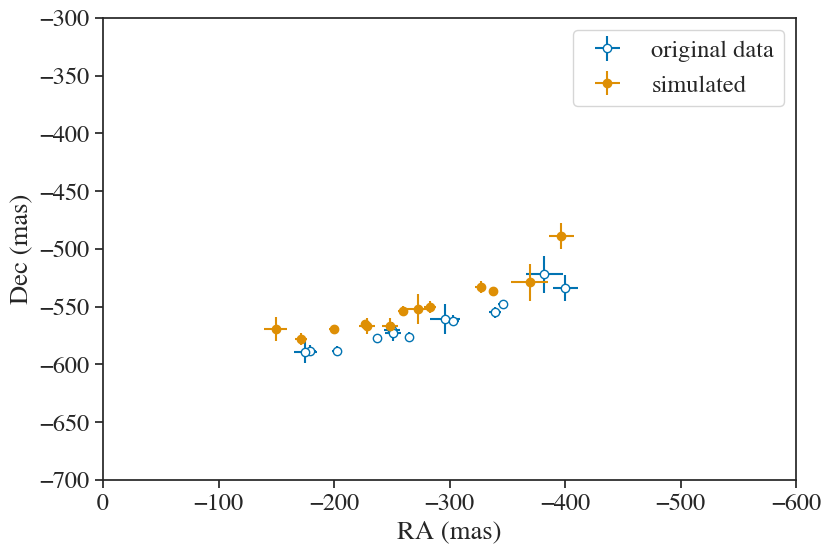

In [8]:
plt.xlim(0, -0.6*1e3)
plt.ylim(-0.7*1e3, -0.3*1e3)
plt.gca().set_aspect(1.)
plt.xlabel("RA (mas)")
plt.ylabel("Dec (mas)")
plt.errorbar(ra, dec, fmt='o', xerr=raerr, yerr=decerr, mfc='white', label='original data')
plt.errorbar(ra_sim, dec_sim, fmt='o', xerr=raerr, yerr=decerr, label='simulated')
plt.legend(loc='best')

In [9]:
pd.DataFrame(data={'object': 1, 'epoch': t, 'raoff': ra_sim, 'raoff_err': raerr, 'decoff': dec_sim, 'decoff_err': decerr,
                'radec_corr': 0.}).to_csv("simulated_data.csv", index=False)

In [27]:
np.savez("simulated_data_params.npz", **init_elements)